Logistic Regrission

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve,auc
from sklearn.model_selection import train_test_split

df=pd.read_csv("/Users/mac/Desktop/Machine Learning/ai-roadmap/content/ml/supervised/05 logistic regression/data/heart_diceases.csv")

In [56]:
#Preview
print("First 5 rows:", df.head())
print("Information:", df.info())
print("Summary:", df.describe())

First 5 rows:    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64 

In [57]:
#checking missing values
missing_per=df.isnull().mean()*100
print("\nPercentage of missing values in each column:")
print(missing_per)



Percentage of missing values in each column:
age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64


In [58]:
# drop columns with more than 80% missing values
columns_to_drop=missing_per[missing_per>80].index
df.drop(columns=columns_to_drop, inplace=True)

#drop rows with missing values is less than 5%
low_missing_cols = missing_per[(missing_per > 0) & (missing_per < 5)].index
df.dropna(subset=low_missing_cols, inplace=True)

In [59]:
#Unique Values
print("\nColumns with unusual distribution or outliers:")
for col in df.columns:
    print(f"Number of unique values in {col}: {df[col].nunique()}")


Columns with unusual distribution or outliers:
Number of unique values in age: 41
Number of unique values in sex: 2
Number of unique values in cp: 4
Number of unique values in trestbps: 49
Number of unique values in chol: 152
Number of unique values in fbs: 2
Number of unique values in restecg: 3
Number of unique values in thalach: 91
Number of unique values in exang: 2
Number of unique values in oldpeak: 40
Number of unique values in slope: 3
Number of unique values in ca: 5
Number of unique values in thal: 4
Number of unique values in target: 2


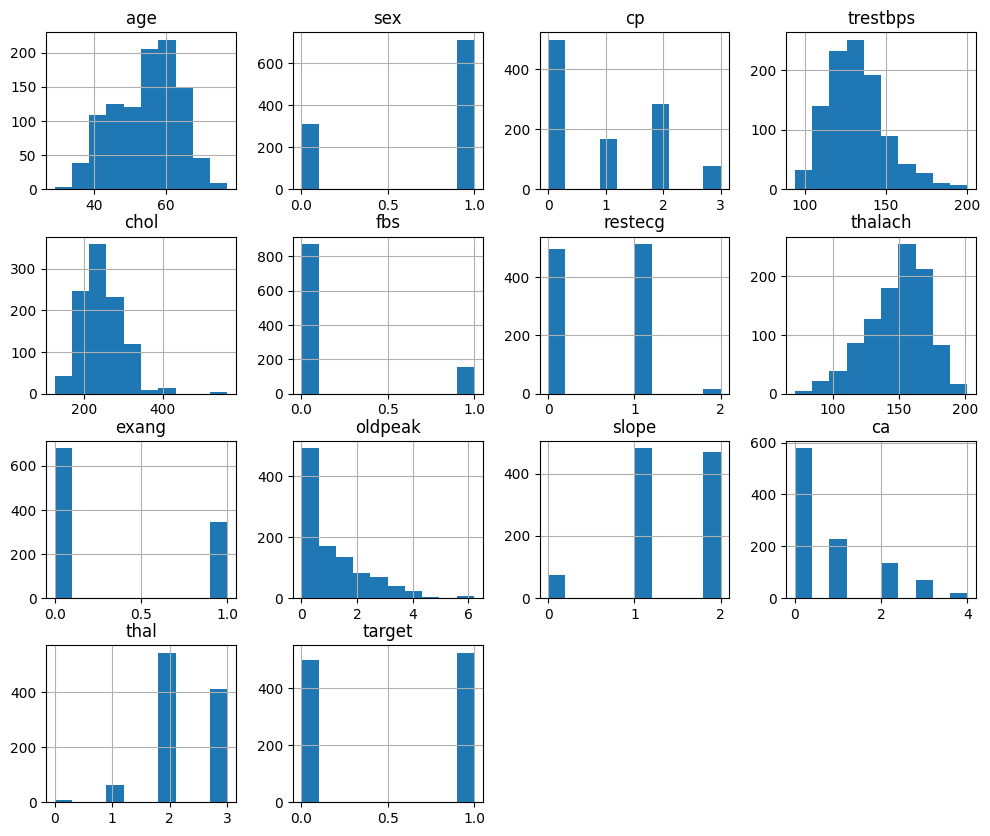

In [60]:
#Visualization
df.hist(figsize=(12,10))
plt.show()

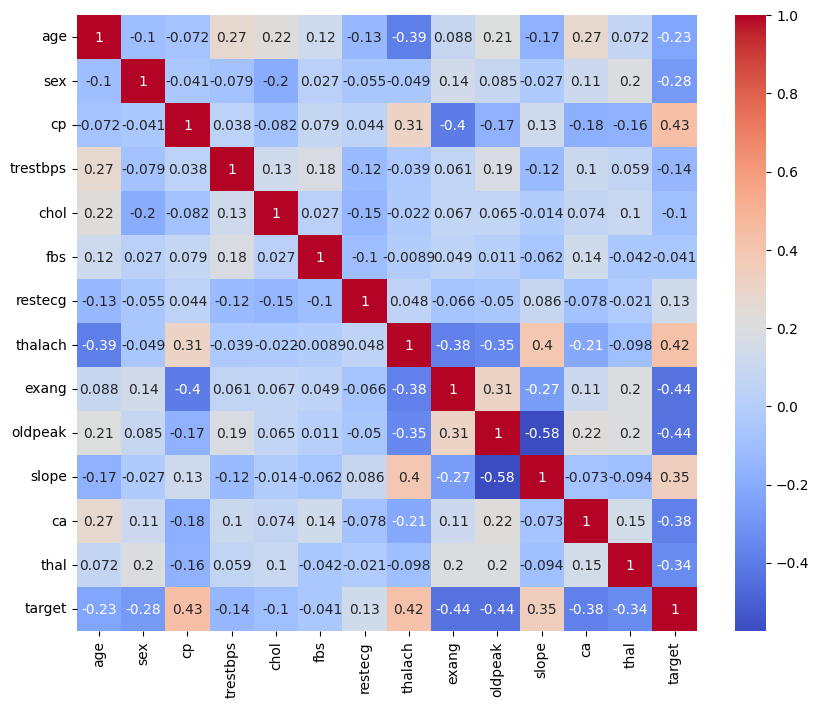

In [61]:
#Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [62]:
########Data Preprocessing
#One-Hot Encoding
df=pd.get_dummies(df, columns=['cp', 'slope', 'thal'], drop_first=True)

#Split features and target
X=df.drop("target", axis=1)
y=df["target"]

#Train-Test Split
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42)

#Scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [63]:
###### Model Building
log_reg=LogisticRegression(solver="liblinear")
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [64]:
##### Model Evaluation

#prediction
y_pred=log_reg.predict(X_test)
y_prob=log_reg.predict_proba(X_test)[:,1]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [65]:
#Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.4975609756097561


In [66]:
#Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      1.00      0.66       102
           1       0.00      0.00      0.00       103

    accuracy                           0.50       205
   macro avg       0.25      0.50      0.33       205
weighted avg       0.25      0.50      0.33       205



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

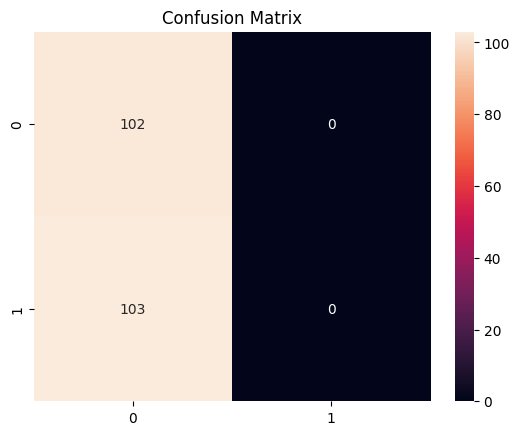

In [67]:
#Confusion matrix
cm=confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

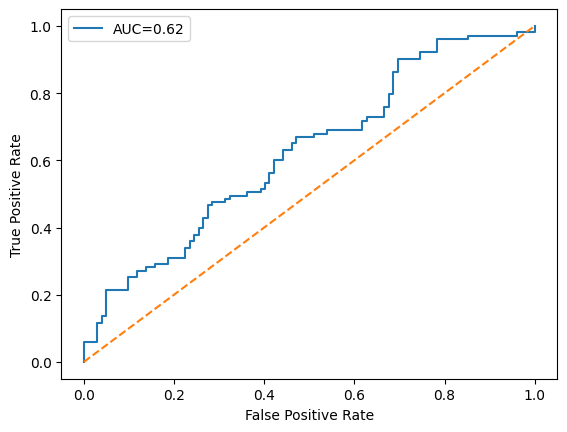

In [68]:
#ROC curve
fpr, tpr, _=roc_curve(y_test, y_prob)
roc_auc=auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [69]:
##### Feature Importance
coefficients=pd.DataFrame({
    "Feature": X.columns,
    "Coefficient":log_reg.coef_[0]
    })

print(coefficients.sort_values(by="Coefficient", ascending=False))

     Feature  Coefficient
11      cp_2     0.801363
12      cp_3     0.598269
16    thal_2     0.589943
6    thalach     0.515219
10      cp_1     0.458852
15    thal_1     0.369245
5    restecg     0.155804
14   slope_2     0.082411
0        age     0.020074
4        fbs    -0.019644
17    thal_3    -0.116689
2   trestbps    -0.273584
7      exang    -0.322702
13   slope_1    -0.374227
3       chol    -0.450362
8    oldpeak    -0.685596
1        sex    -0.724212
9         ca    -0.882732


In [70]:
#RFE (Feature Selection)

selector=RFE(log_reg, n_features_to_select=8)
selector.fit(X_train_scaled, y_train)

selected_features=X.columns[selector.support_]
print(selected_features)


Index(['sex', 'oldpeak', 'ca', 'cp_1', 'cp_2', 'cp_3', 'slope_1', 'thal_2'], dtype='str')


In [74]:
##### Prediction Example
sample_dict = {
    'age': 63,
    'sex': 1,
    'trestbps': 145,
    'chol': 233,
    'fbs': 1,
    'restecg': 0,
    'thalach': 150,
    'exang': 0,
    'oldpeak': 2.3,
    'ca': 0,

    # cp (choose ONE = 1, others = 0)
    'cp_1': 0,
    'cp_2': 0,
    'cp_3': 1,

    # slope
    'slope_1': 0,
    'slope_2': 1,

    # thal
    'thal_1': 0,
    'thal_2': 1,
    'thal_3': 0
}

# Convert to DataFrame
sample = pd.DataFrame([sample_dict])

# Match column order EXACTLY
sample = sample[X.columns]

# Scale
sample_scaled = scaler.transform(sample)

# Predict
prediction = log_reg.predict(sample_scaled)
probability = log_reg.predict_proba(sample_scaled)

print("Heart Disease:", "YES" if prediction[0]==1 else "NO")

Heart Disease: YES


In [72]:
#Hyperparameter Tuning

params={
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid=GridSearchCV(LogisticRegression(), params, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=